# Observando a linha de 21cm

## Instruções

### Instalação:

- Siga as instruções em https://github.com/lbarosi/GNURadioBlocks e instale o bloco FITS_SINK
- Clone este repositório

### Uso

#### Aquisição de Dados

- Ative o ambiente conda: `conda activate gnuradio`
- Execute o gnuradio-companion a partir do terminal
- Abra o flow `minihorn_flow.grc` na pasta gnuradio
- Edite a variável `prefix` para o caminho completo onde você quiser gravar os arquivos, incluindo um prefixo para todos eles. (ex: `../data/raw/GNURADIO/minicorneta_ALT45`)
- Execute o flow por quanto tempo desejar.

#### Análise de dados

- Caso necessário ajuste a variável `obs.backend.controller.local_folder` para apontar para a pasta onde os arquivos foram salvos.
- Ajuste a variável `RTLSDRGNU.name` com o prefixo que você escolheu para os arquivos.
- Caso necessário, edite o tempo da  observação. Por padrão ele considera todas as medidas do dia corrente a partir da meia-noite como sendo parte do mesmo conjunto.
- Pode ser preciso testar valores diferentes da variável `window` para filtrar RFI.

## Inicialização

In [1]:
# Mostra todos os resultados da célula, não apenas o último
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display
InteractiveShell.ast_node_interactivity = "all"
import logging
import os
import sys
import astropy.units as u
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
sys.path.append(os.path.abspath(os.path.join(os.path.split(os.getcwd())[0])))
sys.path.append(os.path.abspath(os.path.join(os.path.split(os.getcwd())[0], "radiotelescope")))
sys.path.append(os.path.abspath(os.path.join(os.path.split(os.getcwd())[0], "radiotelescope/GNURadio")))
from radiotelescope.observations.observations import Observations as Obs
from radiotelescope.instruments import RTLSDRGNU
from radiotelescope.observations.observations import MAD_filter, RFI_filter, plot_mosaic
logger = logging.getLogger("radiotelescope")
handler = logging.StreamHandler()
formatter = logging.Formatter(
        '%(asctime)s %(name)-12s %(levelname)-8s %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)
logger.setLevel(logging.DEBUG)

Para observações conecte o dongle na porta USB local.


## Analisando Dados

In [2]:
# Edite o tempo inicial se necessário.
fuso = RTLSDRGNU.instrument.timezone
t_start = fuso.localize(pd.to_datetime("2022-11-30 00:00:00"))
obs = Obs(t_start=t_start, duration=pd.Timedelta(12, unit="h"))
#obs = Obs(duration=pd.Timedelta(9, unit="h")).initialize()
obs.backend = RTLSDRGNU
# Edite este nome com o prefixo que você usou no gnuradio.
RTLSDRGNU.name = "UIRAPURU"
# Se necessário, altere esta variável para apontar para os seus dados.
obs.backend.controller.local_folder = "../../UIRAPURU/data/raw/"
RTLSDRGNU.instrument.Alt = 76
# Carrega todas as observações feitas no período determinado com o prefixo indicado.
obs.initialize().load_observation(extension="fit");

In [3]:
obs.timezone
obs.t_start
obs.t_end

<DstTzInfo 'America/Recife' LMT-1 day, 21:40:00 STD>

Timestamp('2022-11-30 00:00:00-0300', tz='America/Recife')

Timestamp('2022-11-30 12:00:00-0300', tz='America/Recife')

In [4]:
obs.data.head(3)

,1173.500000,1173.504888,1173.509775,1173.514663,1173.519550,1173.524438,1173.529326,1173.534213,1173.539101,1173.543988,...,1178.456012,1178.460899,1178.465787,1178.470674,1178.475562,1178.480450,1178.485337,1178.490225,1178.495112,1178.500000
2022-11-30 10:46:39.786429102,-67.466103,-67.463997,-67.763000,-67.767799,-67.610001,-67.687302,-67.564102,-67.209602,-67.138702,-67.024803,...,-67.714104,-67.723297,-67.780296,-67.919197,-68.056602,-68.024597,-67.716904,-67.661301,-67.733200,-67.632896
2022-11-30 10:46:39.788520554,-67.553001,-67.399101,-67.464699,-67.437103,-67.385498,-67.417999,-67.133202,-67.072601,-67.325897,-67.375999,...,-67.524498,-67.756897,-67.726898,-67.624901,-67.566704,-67.525703,-67.772697,-67.792297,-67.633598,-67.625397
2022-11-30 10:46:39.790647418,-67.598999,-67.513100,-67.231400,-67.097298,-67.139801,-67.208801,-67.264099,-67.391098,-67.386803,-67.400398,...,-67.466400,-67.408302,-67.503197,-67.553001,-67.351601,-67.372398,-67.588799,-67.627296,-67.504204,-67.437897


In [5]:
obs.data.index

DatetimeIndex(['2022-11-30 10:46:39.786429102',
               '2022-11-30 10:46:39.788520554',
               '2022-11-30 10:46:39.790647418',
               '2022-11-30 10:46:39.792717015',
               '2022-11-30 10:46:39.794800850',
               '2022-11-30 10:46:39.796898038',
               '2022-11-30 10:46:39.798997196',
               '2022-11-30 10:46:39.801094633',
               '2022-11-30 10:46:39.803195500',
               '2022-11-30 10:46:39.805286211',
               ...
               '2022-11-30 13:54:44.847718673',
               '2022-11-30 13:54:44.849816384',
               '2022-11-30 13:54:44.851916226',
               '2022-11-30 13:54:44.854012727',
               '2022-11-30 13:54:44.856100558',
               '2022-11-30 13:54:44.858205995',
               '2022-11-30 13:54:44.860298505',
               '2022-11-30 13:54:44.862387058',
               '2022-11-30 13:54:44.864496441',
               '2022-11-30 13:54:44.866582491'],
              dtype=

In [19]:
from astropy.time import Time
Time(df_sky.TIME.min(), scale="utc")

<Time object: scale='utc' format='datetime' value=2022-11-30 13:24:16.786412>

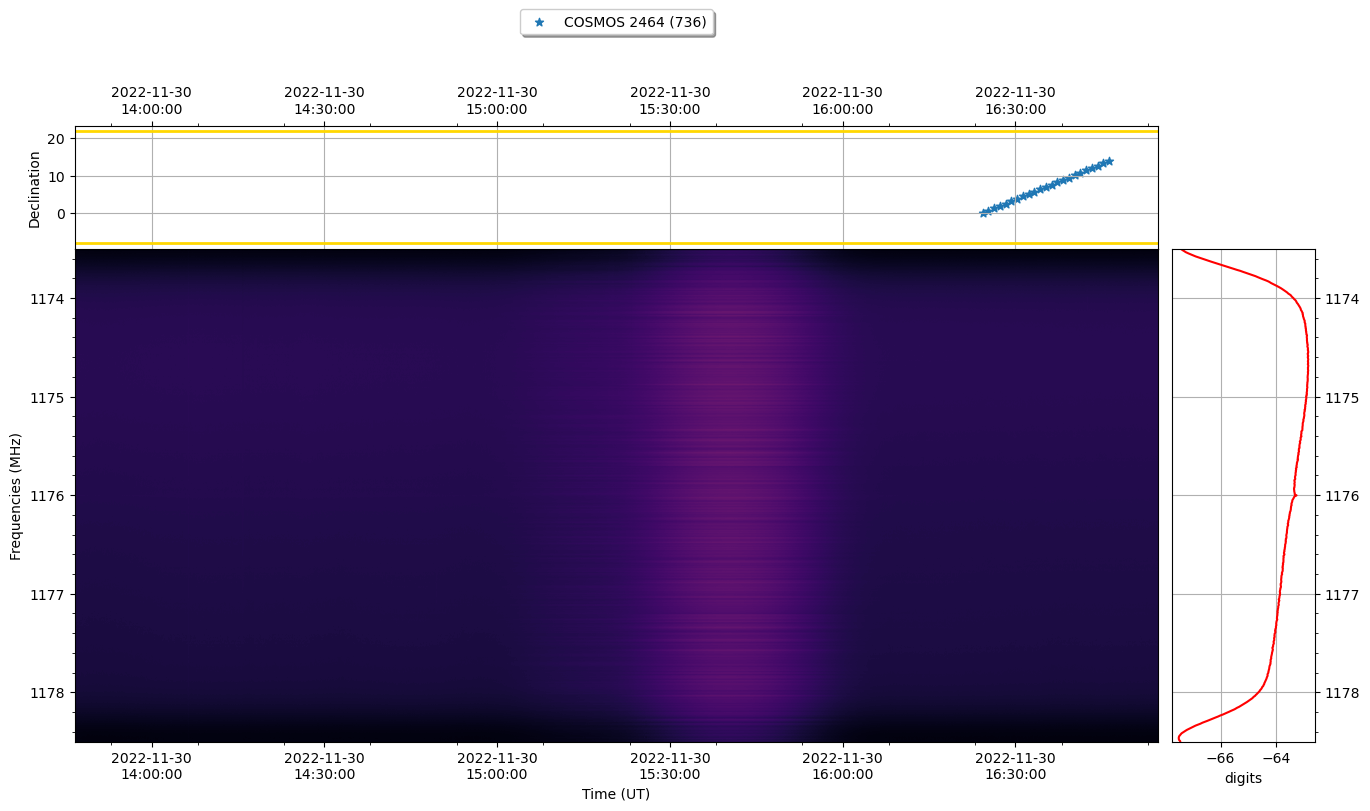

In [7]:
# Comparação do sinal recebido com objetos no céu.
obs.make_sky().sky.plot_timeseries(obs.data);

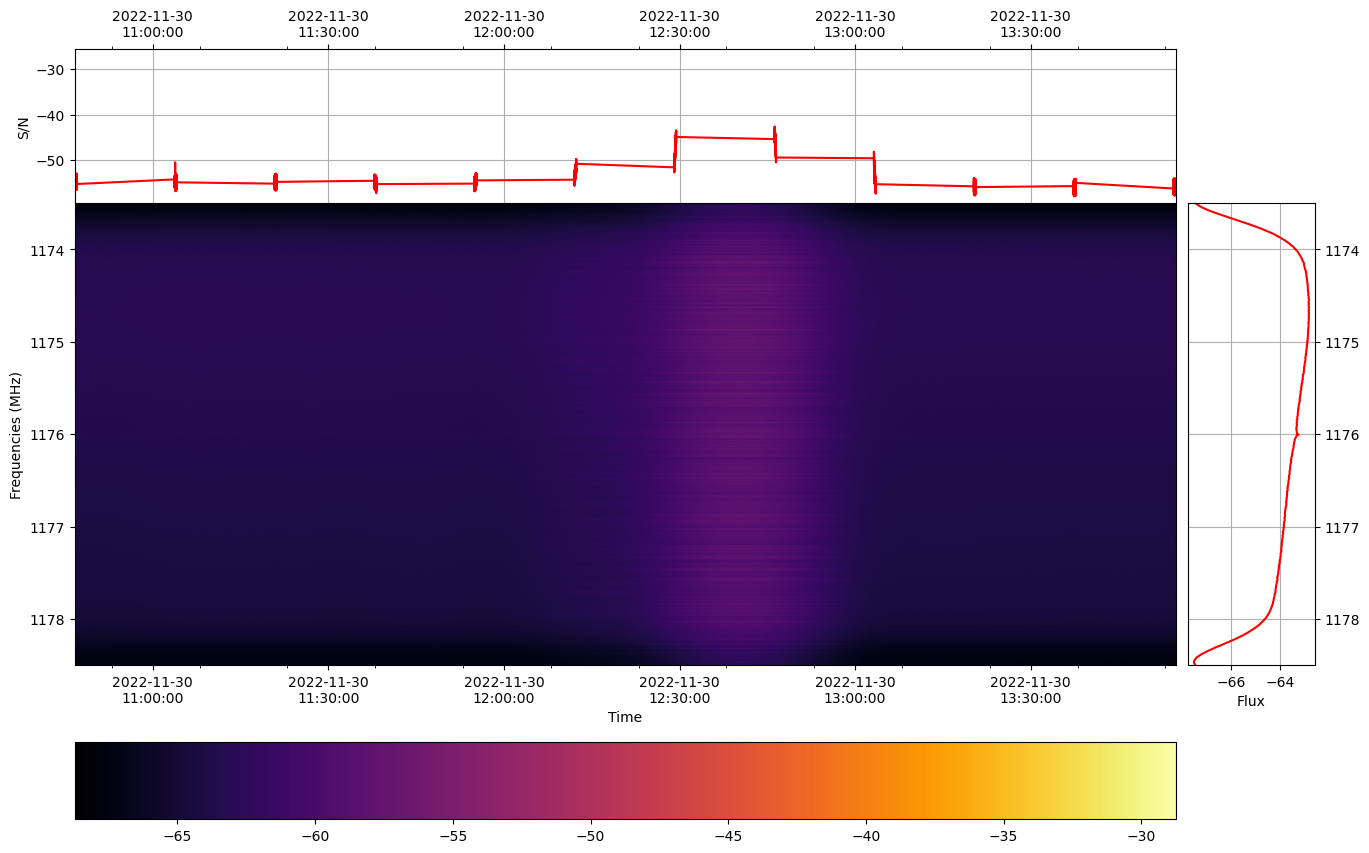

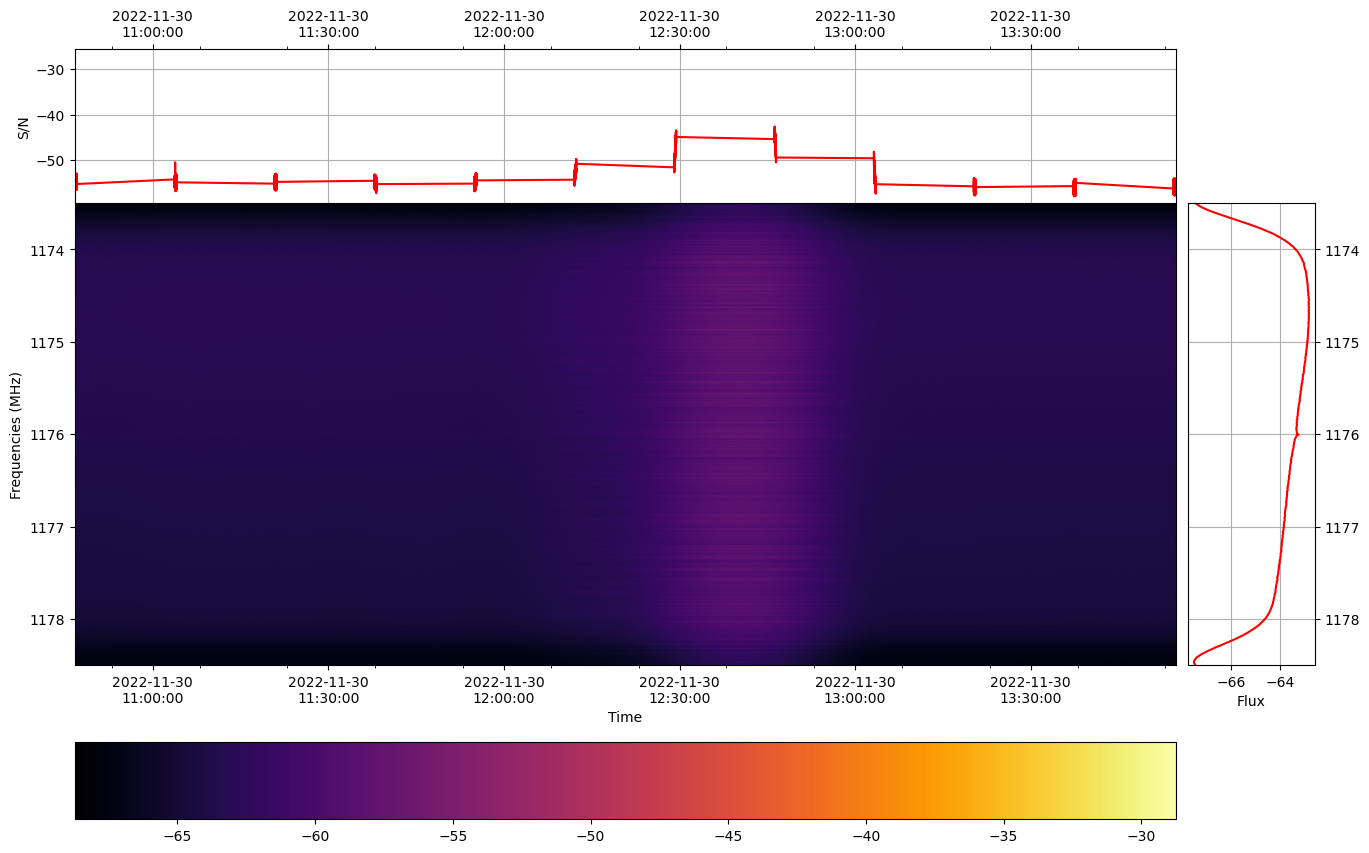

In [8]:
obs.plot_waterfall(obs.data)

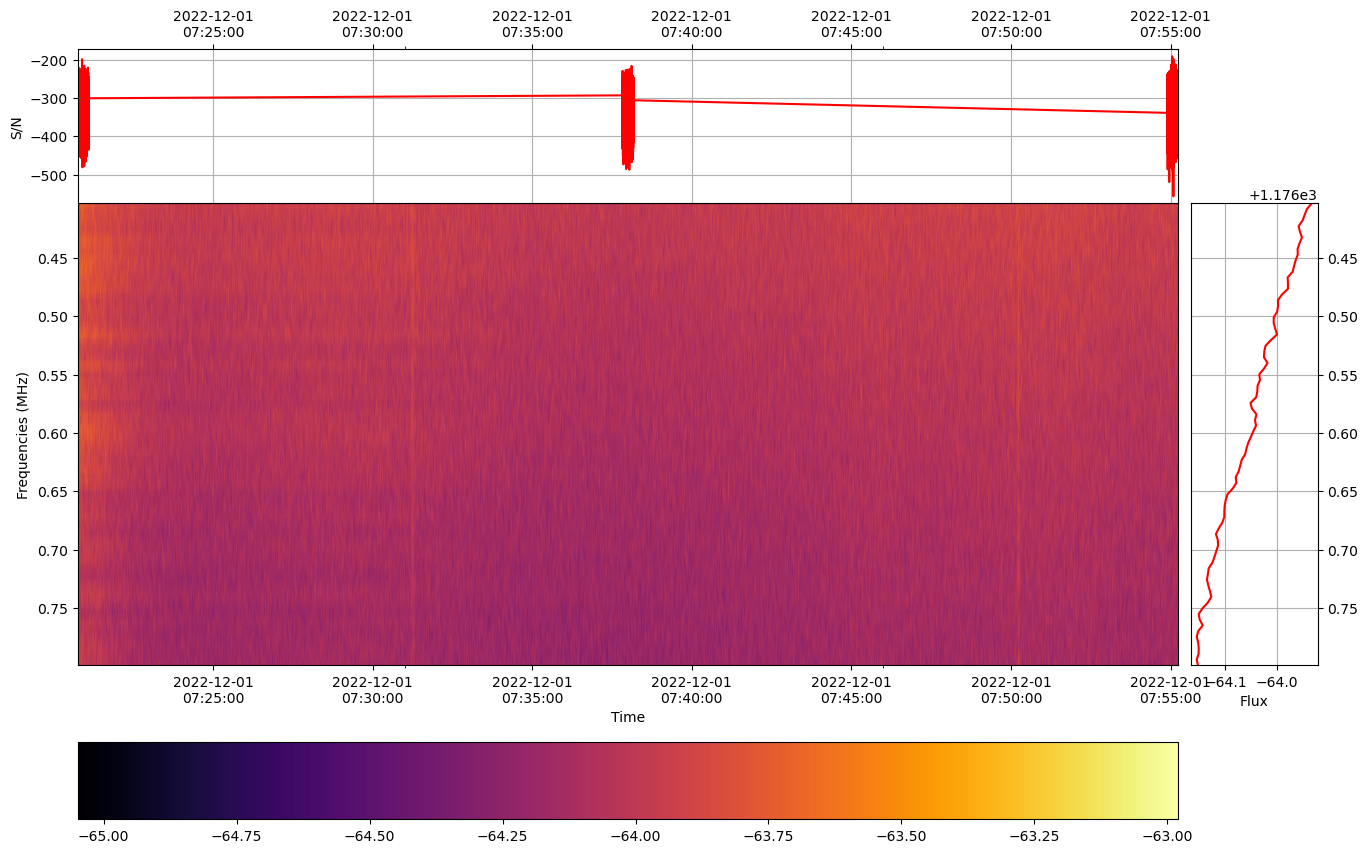

In [20]:
obs.plot_waterfall(obs.data.iloc[250000:280000, :], freqs=[1176.4, 1176.8]);

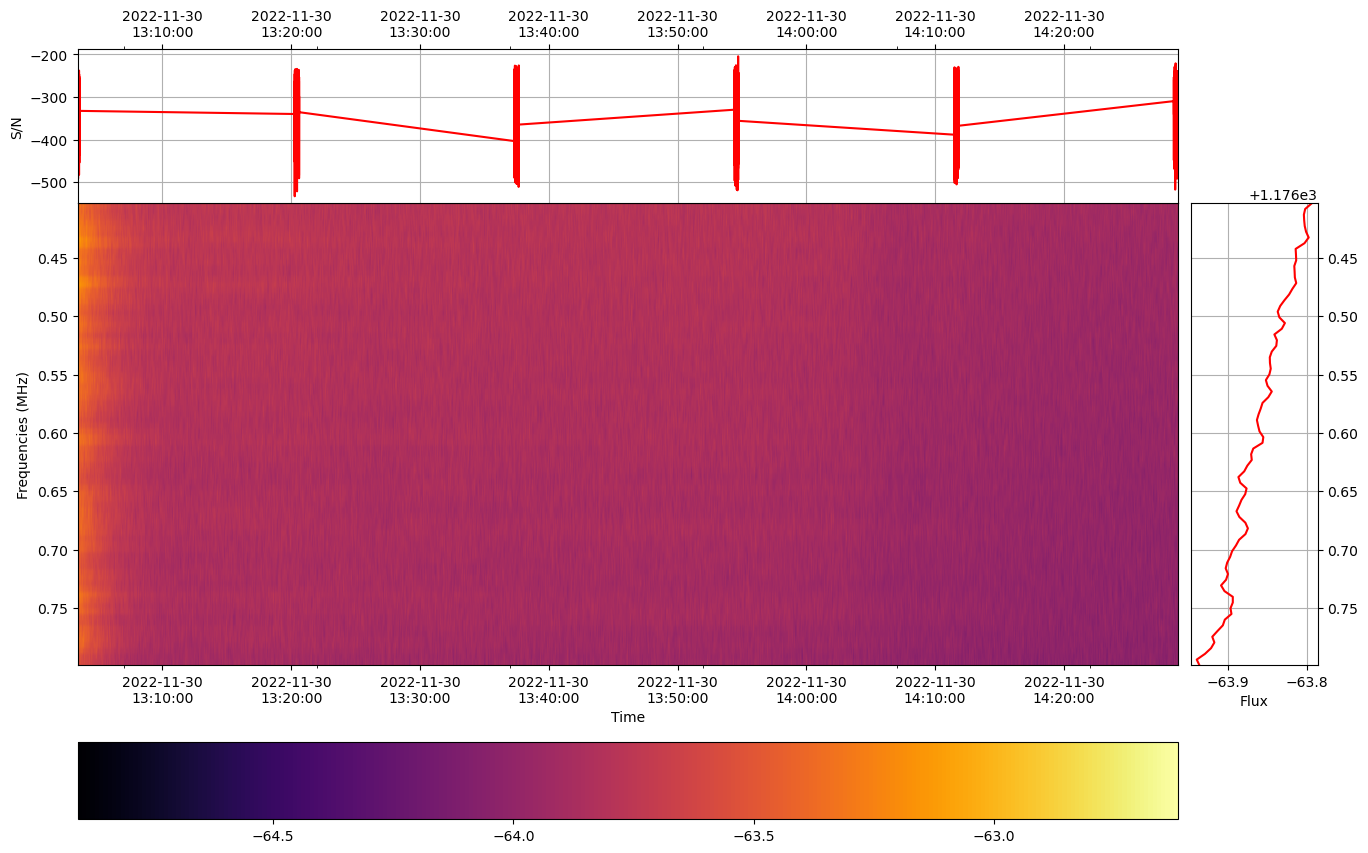

In [149]:
obs.plot_waterfall(obs.data.iloc[86000:140000, :], freqs=[1176.4, 1176.8]);

In [116]:
data = obs.data.iloc[110000:140000, :]
freqs = data.columns.values
baseline = sp.signal.savgol_filter(data.median(axis=0), window_length=81, polyorder=3, mode="nearest")
data_sub = data.subtract(baseline, axis=1)

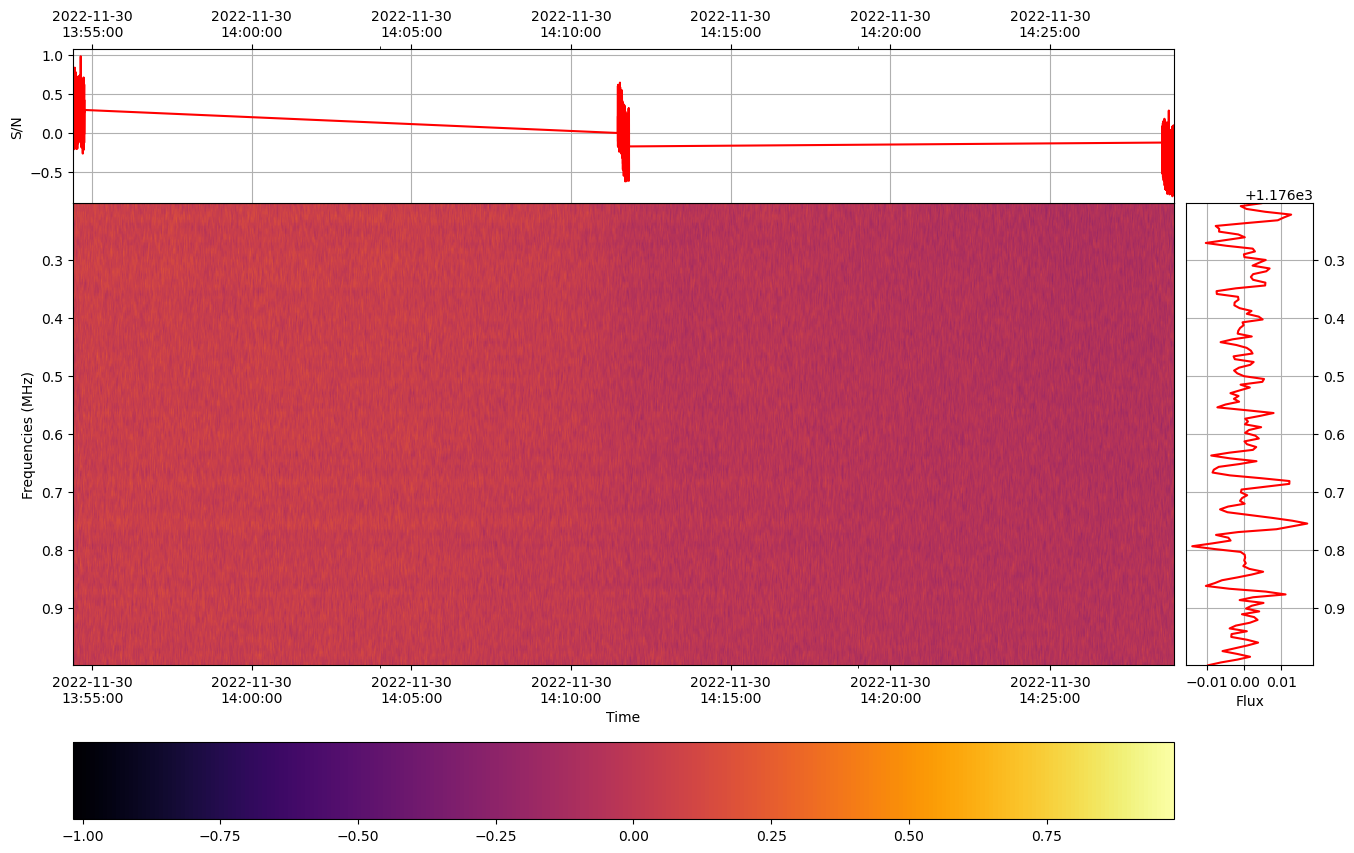

In [140]:
obs.plot_waterfall(data_sub, freqs=[1176.2, 1177]);